In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'C:\\Users\\DEL\\Desktop\\my_python_project\\data'

In [3]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
df['treatment'] = np.where(df['Glucose'] < 140, 'Metformin_Group', 'Non_Metformin')

In [5]:
df['outcome'] = df['Outcome']

In [6]:
df.groupby('treatment')['outcome'].mean()

treatment
Metformin_Group    0.230228
Non_Metformin      0.688442
Name: outcome, dtype: float64

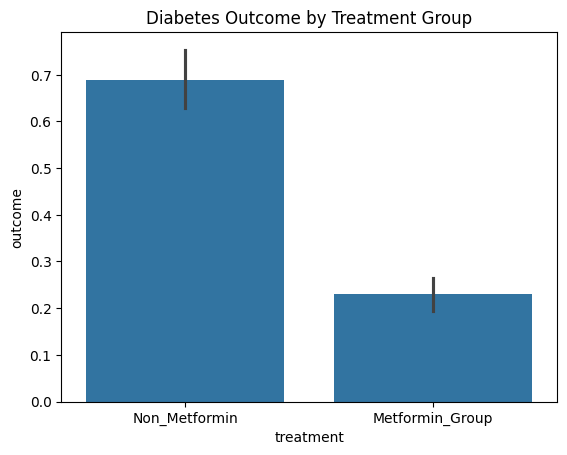

In [7]:
sns.barplot(x='treatment', y='outcome', data=df)
plt.title("Diabetes Outcome by Treatment Group")
plt.show()

In [8]:
table = pd.crosstab(df['treatment'], df['outcome'])
table

outcome,0,1
treatment,,
Metformin_Group,438,131
Non_Metformin,62,137


In [9]:
a = table.iloc[0,0]
b = table.iloc[0,1]
c = table.iloc[1,0]
d = table.iloc[1,1]

odds_ratio = (a*d)/(b*c)
odds_ratio

np.float64(7.388081753262743)

In [10]:
import math

se = math.sqrt(1/a + 1/b + 1/c + 1/d)

log_or = math.log(odds_ratio)

ci_lower = math.exp(log_or - 1.96 * se)
ci_upper = math.exp(log_or + 1.96 * se)

print("OR:", odds_ratio)
print("CI:", (ci_lower, ci_upper))

OR: 7.388081753262743
CI: (5.165284236553783, 10.567424655281222)


In [11]:
df[['Glucose','BMI','Age','BloodPressure']].corr()

,Glucose,BMI,Age,BloodPressure
Glucose,1.000000,0.236171,0.268910,0.225141
BMI,0.236171,1.000000,0.027849,0.286399
Age,0.268910,0.027849,1.000000,0.325135
BloodPressure,0.225141,0.286399,0.325135,1.000000
